<a href="https://colab.research.google.com/github/AlesioRios/Laboratorio-de-Datos-II/blob/main/Lab_de_Datos_II_TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Librerias

In [ ]:
# Instalar gdown (solo es necesario la primera vez)
#!pip install gdown
# Descargar la carpeta con los datos
!gdown --folder --id 1GOJ63mZ6qZGdbb8v5v6bcy3fsbLs8yju
# Cargar el dataset en un DataFrame
import pandas as pd
df = pd.read_pickle('data/house_prices.pkl')

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Retrieving folder contents
Processing file 1wOLyprsRSgN7TD_MRKKQi_4ts4xdXEAG data_description.txt
Processing file 1Ub5YOgvDgOb3WaTeYLs66f3MaPaQ36DF house_prices.pkl
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1wOLyprsRSgN7TD_MRKKQi_4ts4xdXEAG
To: /content/data/data_description.txt
100% 13.4k/13.4k [00:00<00:00, 24.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ub5YOgvDgOb3WaTeYLs66f3MaPaQ36DF
To: /content/data/house_prices.pkl
100% 140k/140k [00:00<00:00, 23.2MB/s]
Download completed


In [ ]:
!pip install category_encoders

In [ ]:
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from category_encoders import BinaryEncoder

#Ejercicio 1

##Seccion 1.1

In [ ]:
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")


Dimensiones del dataset: 1487 filas, 14 columnas


Resumen de variables

Las variables corresponden al dataset de Ames Housing (comúnmente usado en la competencia *House Prices* de Kaggle):

* **SalePrice:** Precio de venta de la propiedad en dólares (variable objetivo / target).
* **MSZoning:** Clasificación general de zonificación del terreno (ej. residencial de baja densidad 'RL', residencial de media densidad 'RM', comercial 'C', etc.).
* **Neighborhood:** Ubicación física o barrio dentro de los límites de la ciudad de Ames (ej. `NAmes`, `CollgCr`, `OldTown`).
* **LotFrontage:** Longitud lineal en pies (ft) de la calle conectada con la propiedad (frente del lote).
* **LotArea:** Tamaño total del lote o terreno en pies cuadrados ($ft^2$).
* **OverallCond:** Calificación general del estado/condición de la vivienda en una escala del 1 (muy pobre) al 10 (muy excelente).
* **YearBuilt:** Año original de construcción de la propiedad.
* **FullBath:** Cantidad de baños completos ubicados por encima del nivel del suelo (*above ground*).
* **BedroomAbvGr:** Cantidad de dormitorios ubicados por encima del nivel del suelo (excluye dormitorios en el sótano/basement).
* **GarageQual:** Calidad del garaje (ej. `Ex` Excelente, `Gd` Bueno, `TA` Típico/Promedio, `Fa` Regular, `Po` Pobre, `NA` Sin garaje).
* **GarageArea:** Tamaño total del garaje en pies cuadrados ($ft^2$).
* **PoolArea:** Superficie de la piscina en pies cuadrados ($ft^2$).
* **PoolQC:** Calidad de la piscina (ej. `Ex`, `Gd`, `TA`, `Fa`, `NA` si no tiene piscina).
* **Fence:** Calidad y privacidad de la cerca o cercado (ej. `GdPrv` Buena privacidad, `MnPrv` Mínima privacidad, `GdWo` Buena madera, `MnWw` Mínima madera/alambre, `NA` Sin cerca).


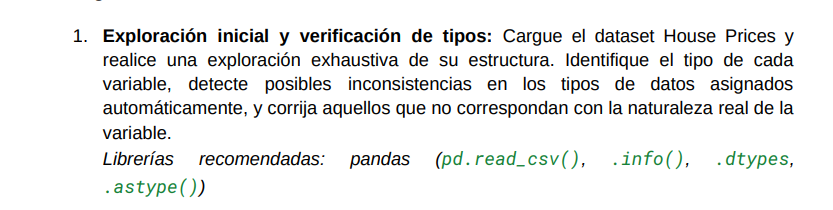

In [ ]:
df.head()

,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
0,87500,RL,NAmes,NaN,8544,4,1949,2,2,TA,400,0,NaN,NaN
1,164990,RL,CollgCr,65.0,8767,5,2005,2,3,TA,400,0,NaN,NaN
2,144000,RM,CollgCr,NaN,4435,5,2003,1,1,TA,420,0,NaN,NaN
3,307000,rL,Somerst,75.0,10084,5,2004,2,3,TA,636,0,NaN,NaN
4,130500,RL,Sawyer,NaN,13517,8,1976,2,3,TA,475,0,NaN,NaN


In [ ]:
def armar_resumen(df):
  """Construye la tabla de resumen de tipos y faltantes, manteniendo
  el % como numérico (para poder aplicarle color o graficarlo después)."""
  resumen = pd.DataFrame({
      'Tipo de Dato': df.dtypes.astype(str),
      'Datos Válidos (No Nulos)': df.notna().sum(),
      'Datos Faltantes (Nulos)': df.isna().sum(),
      '% de Faltantes': (df.isna().sum() / len(df) * 100).round(2),
  })
  return resumen.sort_values(by='Datos Faltantes (Nulos)', ascending=False)


def graficar_faltantes(resumen, umbral=0):
  """Barra horizontal con el % de faltantes por columna, para tener
  una lectura visual rápida antes de entrar al detalle de la tabla.
  umbral filtra columnas con menos de ese % (para no saturar el gráfico
  con columnas que tienen 0 o casi 0 faltantes)."""
  datos = resumen[resumen['% de Faltantes'] > umbral].sort_values('% de Faltantes')
  fig, ax = plt.subplots(figsize=(8, max(3, len(datos) * 0.3)))
  ax.barh(datos.index, datos['% de Faltantes'], color='#D85A30')
  ax.set_xlabel('% de Faltantes')
  ax.set_title('Variables con valores faltantes')
  for i, v in enumerate(datos['% de Faltantes']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
  plt.tight_layout()
  plt.show()


def explorar_categoricas(df, columnas=None, top_n=10):
  """Muestra value_counts de cada columna categórica, para detectar
  inconsistencias de nomenclatura (mayúsculas, espacios, typos) —
  consigna 1.2. Si no se pasan columnas, usa todas las object/category."""
  if columnas is None:
    columnas = df.select_dtypes(include=['object', 'category']).columns
  for col in columnas:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False).head(top_n))
    print()

def graficar_antes_despues_categorias(antes_crudo, despues, orden_final,
                                        categoria_nueva='NONE',
                                        categorias_fusionadas=('NA', 'NAN')):
  """Grafica en dos paneles lado a lado la distribución de una variable
  categórica: a la izquierda, las categorías originales (incluyendo el
  faltante real, mostrado como 'NAN', y la categoría de texto 'NA' por
  separado); a la derecha, la distribución final ya unificada. Resalta
  en color distinto las categorías afectadas por la transformación."""

  normalizado = antes_crudo.astype('string').str.strip().str.upper()
  normalizado = normalizado.fillna('NAN')
  conteo_antes = normalizado.value_counts().sort_values(ascending=False)

  conteo_despues = despues.value_counts().reindex(orden_final, fill_value=0)

  color_normal, color_afectado = '#5F5E5A', '#D85A30'
  colores_antes = [color_afectado if c in categorias_fusionadas else color_normal for c in conteo_antes.index]
  colores_despues = [color_afectado if c == categoria_nueva else color_normal for c in conteo_despues.index]

  fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

  axes[0].barh(conteo_antes.index.astype(str), conteo_antes.values, color=colores_antes)
  axes[0].invert_yaxis()
  axes[0].set_title('Antes: categorías originales')
  axes[0].set_xlabel('Cantidad de viviendas')
  for i, v in enumerate(conteo_antes.values):
    axes[0].text(v + max(conteo_antes.values) * 0.01, i, str(v), va='center', fontsize=9)

  axes[1].barh(conteo_despues.index.astype(str), conteo_despues.values, color=colores_despues)
  axes[1].invert_yaxis()
  axes[1].set_title('Después: categorías unificadas')
  axes[1].set_xlabel('Cantidad de viviendas')
  for i, v in enumerate(conteo_despues.values):
    axes[1].text(v + max(conteo_despues.values) * 0.01, i, str(v), va='center', fontsize=9)

  plt.tight_layout()
  plt.show()

In [ ]:
df.info()

In [ ]:
df['SalePrice'] = df['SalePrice'].astype(int)
df['LotFrontage'] = pd.to_numeric(df['LotFrontage'], errors='coerce')

#Chequeamos que son int64 y float64 respectivamente
assert df['SalePrice'].dtype == 'int64'
assert df['LotFrontage'].dtype == 'float64'

resumen = armar_resumen(df)

display(resumen)

Despues de realizar un analisis de la estructura del dataset y los tipos de datos para cada variable, podemos agruparlas de la siguiente manera:

**Numericas**

Enteros:


*   SalePrice
* LotArea
* YearBuilt
* BedroomAbvGR
* FullBath
* PoolArea
* GarageArea
* LotFrontage (en todos los registros, la parte decimal es 0)

**Categoricas**

Nominales:
*   NeighborHood
*   MSZoning

Ordinales:
*   OverallCond (codificada numericamente)
* GarageQual
* PoolQC
* Fence








##Seccion 1.2

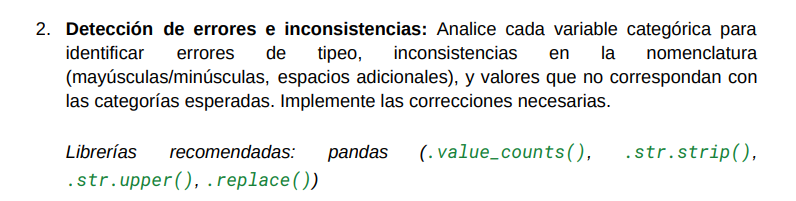

In [ ]:
#Fence

df['Fence'].value_counts(dropna = False)

#En esta variable vemos que hay dos registros que se refieren a lo mismo (Nan y nan). Por eso primero vamos a juntarlos todos con el mismo nombre, ya
#que ambos hacen referencia a casas que no tienen un cercado y despues les pondremos el nombre 'NONE' para mantener la consistencia en el dataset



,count
Fence,
NaN,1189
MnPrv,161
GdPrv,62
GdWo,54
MnWw,11
nan,10


In [ ]:
#Eliminamos espacios en blanco y volvemos a probar
df['Fence']  = df['Fence'].str.strip()

#Comprobamos que realmente se tratan de cadenas de texto y no de valores nulos reales
df_filtrado = df[df['Fence'] == 'nan']

df_filtrado.head()

,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
220,131500,RM,CollgCr,36.0,4435,5,2003,1,1,TA,420,0,NaN,nan
327,135000,RL,Edwards,60.0,8172,6,1954,2,4,TA,548,0,NaN,nan
356,149900,RL,Edwards,134.0,17755,4,1959,1,3,TA,528,0,NaN,nan
503,87000,RM,IDOTRR,50.0,5000,6,1941,1,2,TA,360,0,NaN,nan
789,133000,Rh,NAmes,34.0,4058,5,1998,1,1,TA,367,0,NaN,nan


In [ ]:
#Ahora si reemplazamos y unificamos
df['Fence'] = df['Fence'].replace({'nan' : 'NONE'})
df['Fence'].value_counts()

df['Fence'].value_counts(dropna = False)


,count
Fence,
NaN,1189
MnPrv,161
GdPrv,62
GdWo,54
MnWw,11
NONE,10


In [ ]:
#Neighborhood
print('Frecuencias originales:')
print(df['Neighborhood'].value_counts())

#Al comparar los resultados con la documentacion oficial del dataset, todos los registros estan correctos excepto dos. Al final de la lista se repiten
#'NAmes' y 'BrkSide'

#Verificamos si hay algun espacio en blanco
df['Neighborhood']  = df['Neighborhood'].str.strip()
print('\nFrecuencias despues de aplicar str.strip():')
df['Neighborhood'].value_counts()

#Podemos comprobar que efectivamente los 3 registros adicionales se debian a la presencai de espacios en blanco en los registros, por lo que ya estan bien unificados

Frecuencias originales:
Neighborhood
NAmes        225
CollgCr      156
OldTown      114
Edwards      102
Somerst       87
Gilbert       81
NridgHt       78
NWAmes        77
Sawyer        75
SawyerW       60
BrkSide       57
Crawfor       51
Mitchel       50
NoRidge       42
Timber        38
IDOTRR        37
ClearCr       28
SWISU         26
StoneBr       25
MeadowV       18
Blmngtn       18
BrDale        17
Veenker       11
NPkVill        9
Blueste        2
 NAmes         2
 BrkSide       1
Name: count, dtype: int64

Frecuencias despues de aplicar str.strip():


,count
Neighborhood,
NAmes,227
CollgCr,156
OldTown,114
Edwards,102
Somerst,87
Gilbert,81
NridgHt,78
NWAmes,77
Sawyer,75


In [ ]:
#MSZoning

df['MSZoning'].value_counts()

#Comparando con la documentacion oficial, todos los registros tendrian que estar en mayuscula. Sin embargo, en el dataset hay registros que hacen referencia
# a las zonas correctas pero escritas en minuscula


,count
MSZoning,
RL,1168
RM,222
FV,66
C (all),10
Rh,10
RH,6
rL,5


In [ ]:
#Ponemos todo en mayusculas
df['MSZoning'] = df['MSZoning'].str.upper()

df['MSZoning'].value_counts()

,count
MSZoning,
RL,1173
RM,222
FV,66
RH,16
C (ALL),10


In [ ]:
variable = df['SalePrice']
print(variable)

0        87500
1       164990
2       144000
3       307000
4       130500
         ...  
1482    270000
1483    109008
1484    102000
1485    165000
1486     81000
Name: SalePrice, Length: 1487, dtype: object


##Seccion 1.3

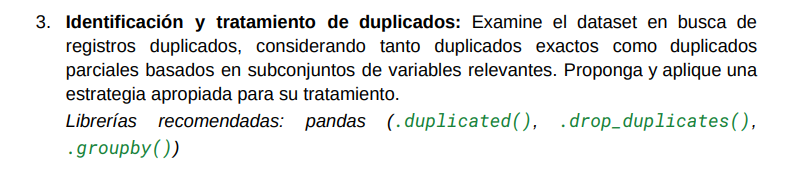

In [ ]:
#Evaluamos cuantos registros estan duplicados

cant_filas_duplicadas = df.duplicated().sum()
print(f'Cantidad de filas duplicadas: {cant_filas_duplicadas}')
# Filtrar el DataFrame para conservar todas las filas duplicadas


duplicados = df[df.duplicated(keep=False)]
frecuencia_duplicados = (
    duplicados
    .groupby(list(df.columns), dropna=False)
    .size()
    .sort_values(ascending=False)
)

frecuencia_duplicados


len(duplicados)
#frecuencia_duplicados['frecuencia'].value_counts()

In [ ]:
duplicados_ordenados = duplicados.sort_values(
    by=list(df.columns)
)

duplicados_ordenados

Como primer paso se verificó la existencia de registros duplicados mediante df.duplicated(). Se identificaron 24 registros duplicados respecto de una aparición anterior. Al utilizar keep=False, se observó que existen 48 observaciones involucradas, correspondientes a 24 pares de filas idénticas.
Además, se comprobó que todos los grupos tienen una frecuencia de 2, es decir, no existen combinaciones que aparezcan tres o más veces.

A continuación, se decidió investigar si determinadas variables presentaban coincidencias parciales particularmente relevantes.

La idea no fue simplemente buscar las variables cuyos valores aparecen más veces, sino identificar aquellas que poseen una mayor capacidad discriminativa entre viviendas.

Una variable es más interesante para este análisis cuando sus valores representan características relativamente específicas de una propiedad. Por el contrario, variables con pocos valores posibles, como una escala de calidad o una cantidad reducida de categorías, pueden presentar muchas repeticiones simplemente por su naturaleza.

Por este motivo, se decidió analizar progresivamente diferentes grupos de variables, desde características físicas más específicas hacia características estructurales y contextuales.

In [ ]:
#Variables de cada nivel
variables_nivel_1 = [
    'LotFrontage',
    'LotArea',
    'GarageArea'
]

variables_nivel_2 = [
    'LotFrontage',
    'LotArea',
    'GarageArea',
    'YearBuilt',
    'OverallCond'
]

variables_nivel_3 = [
    'LotFrontage',
    'LotArea',
    'GarageArea',
    'YearBuilt',
    'OverallCond',
    'Neighborhood',
    'SalePrice'
]


#Función para obtener las frecuencias de los grupos duplicados
def obtener_frecuencias(df, variables):
    frecuencias = (df.groupby(variables, dropna=False).size())
    frecuencias = frecuencias[frecuencias > 1]
    return frecuencias.value_counts().sort_index()


#Obtener distribución de frecuencias para cada nivel
freq_nivel_1 = obtener_frecuencias(df, variables_nivel_1)
freq_nivel_2 = obtener_frecuencias(df, variables_nivel_2)
freq_nivel_3 = obtener_frecuencias(df, variables_nivel_3)


#Unir los tres niveles
tabla_frecuencias = pd.concat(
    [freq_nivel_1, freq_nivel_2, freq_nivel_3], axis=1)

tabla_frecuencias.columns = ['Nivel 1', 'Nivel 2', 'Nivel 3']
tabla_frecuencias = tabla_frecuencias.fillna(0)

In [ ]:
ax = tabla_frecuencias.plot(
    kind='bar',
    figsize=(10, 4),
    width=0.8
)

plt.xlabel('Frecuencia de repetición')
plt.ylabel('Cantidad de grupos')
plt.title('Evolución de los grupos duplicados por nivel')
plt.xticks(rotation=0)
plt.legend(title='Nivel')

plt.tight_layout()
plt.show()

Nivel 1 — Características físicas:
Al analizar coincidencias utilizando dimensiones físicas concretas de una propiedad, se encontraron grupos con frecuencias de repetición de hasta 8 observaciones. Esto muestra que varias viviendas pueden compartir simultáneamente determinadas características, por lo que una coincidencia parcial no resulta suficiente para considerarlas duplicados.

Nivel 2 — Características estructurales:
Al incorporar información adicional relacionada con las características estructurales de las viviendas, las coincidencias disminuyeron considerablemente. Los grupos de mayor frecuencia desaparecieron y la máxima frecuencia pasó a ser 3. Esto indica que parte de las coincidencias observadas inicialmente podían diferenciarse al considerar información adicional.

Nivel 3 — Contexto y precio:
Finalmente, al incorporar información contextual y el precio de venta, todas las coincidencias restantes quedaron reducidas a pares. Esto evidencia que, a medida que se incorporan variables adicionales, aumenta la capacidad de distinguir entre observaciones que inicialmente parecían duplicadas.

En conclusion el análisis no permite determinar de manera definitiva si los 24 pares corresponden a la misma vivienda registrada dos veces o a viviendas diferentes que coinciden en todas las variables disponibles.

Esto es especialmente relevante porque se trabaja con un subconjunto reducido de variables y no se dispone de un identificador único de la propiedad ni del dataset original para contrastar las observaciones.

En consecuencia, y ante la ausencia de evidencia suficiente para afirmar que se trata de errores de carga o duplicaciones accidentales, se decidió conservar los 48 registros involucrados en los pares duplicados.

La decisión evita eliminar observaciones potencialmente válidas basándose únicamente en la igualdad de las variables disponibles.

#Ejercicio 2

##Seccion 2.1


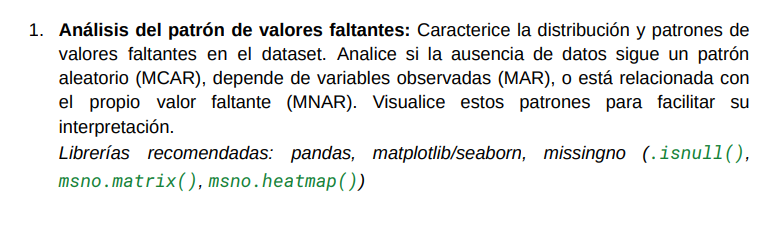

Primero comprobamos los valores faltantes

,Tipo de Dato,Datos Válidos (No Nulos),Datos Faltantes (Nulos),% de Faltantes
PoolQC,object,7,1480,99.53
Fence,object,298,1189,79.96
LotFrontage,float64,1223,264,17.75
GarageQual,object,1411,76,5.11
MSZoning,object,1487,0,0.00
SalePrice,int64,1487,0,0.00
OverallCond,int64,1487,0,0.00
LotArea,int64,1487,0,0.00
Neighborhood,object,1487,0,0.00
YearBuilt,int64,1487,0,0.00


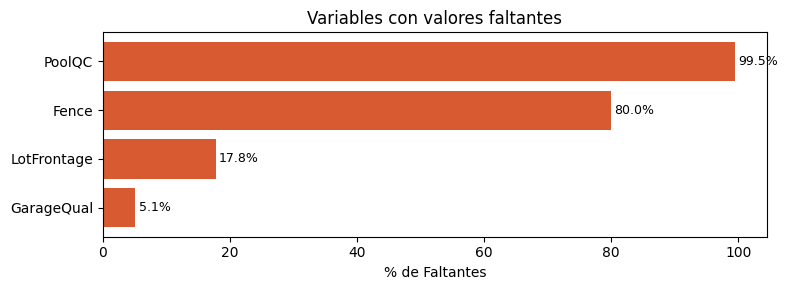

,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
0,87500,RL,NAmes,NaN,8544,4,1949,2,2,TA,400,0,NaN,NaN
1,164990,RL,CollgCr,65.0,8767,5,2005,2,3,TA,400,0,NaN,NaN
2,144000,RM,CollgCr,NaN,4435,5,2003,1,1,TA,420,0,NaN,NaN
3,307000,RL,Somerst,75.0,10084,5,2004,2,3,TA,636,0,NaN,NaN
4,130500,RL,Sawyer,NaN,13517,8,1976,2,3,TA,475,0,NaN,NaN


In [ ]:
resumen = armar_resumen(df)

display(resumen)
graficar_faltantes(resumen, umbral=0)
df.head()


Vemos que la mayoría de las características están completas a excepción de 4, por lo que analizaremos el motivo de la ausencia de datos para estas 4 categorías (MCAR, MNAR, MAR):

Analicemos primero PoolQC. Tiene sentido que todas las casas sin pileta no tengan un valor para esta característica, ya que no se puede calificar una pileta que no existe. Para comprobar si nuestra hipótesis es correcta, visualizamos todas las filas que tengan valores nulos de esta categoría en conjunto con los metros cuadrados de las piletas de dichas casas; si el valor es 0, ¡bingo!, tenemos una MNAR.

In [ ]:
#PoolQC
df_antes = df.copy()
#cambiamos los valoress de piletas sin completar a NONE
df['PoolQC'] = df['PoolQC'].fillna('NONE')
print('\n')
# AHORA filtramos estas filas y escribimos su area de pileta , si realmente la casa no cuenta con pileta , el area deberia ser cero
filas_sin_pileta = df[(df['PoolQC'].isna()) | (df['PoolQC'] == 'NONE')]

display(filas_sin_pileta[['PoolQC', 'PoolArea']])
df['PoolQC'].value_counts(dropna=False)


,PoolQC,PoolArea
0,NONE,0
1,NONE,0
2,NONE,0
3,NONE,0
4,NONE,0
...,...,...
1482,NONE,0
1483,NONE,0
1484,NONE,0
1485,NONE,0


,count
PoolQC,
NONE,1480
Gd,3
Ex,2
Fa,2


Ahora imprimimos todos los valores nulos de 'fence':



In [ ]:
#Fence

df['Fence'].value_counts(dropna = False)

filas_fence_nan = df[df['Fence'].isna()]

# Muestra todas las filas resultantes en el notebook
display(filas_fence_nan)


,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
0,87500,RL,NAmes,NaN,8544,4,1949,2,2,TA,400,0,NONE,NaN
1,164990,RL,CollgCr,65.0,8767,5,2005,2,3,TA,400,0,NONE,NaN
2,144000,RM,CollgCr,NaN,4435,5,2003,1,1,TA,420,0,NONE,NaN
3,307000,RL,Somerst,75.0,10084,5,2004,2,3,TA,636,0,NONE,NaN
4,130500,RL,Sawyer,NaN,13517,8,1976,2,3,TA,475,0,NONE,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1479,155000,FV,Somerst,24.0,2572,5,1999,2,3,TA,484,0,NONE,NaN
1482,270000,RL,Timber,85.0,14536,5,2002,2,3,TA,808,0,NONE,NaN
1483,109008,RL,NAmes,77.0,8593,6,1957,1,3,TA,352,0,NONE,NaN
1484,102000,RL,Edwards,67.0,8877,5,1951,1,2,TA,396,0,NONE,NaN


Analizando la descripcion del dataset y explorando la ciudad de Ames por google maps, podemos llegar a la conclusión de que los NaN son, efectivamente las casas que no cuentan con cerco. nos encontramos ante un UN caso de MNAR  por lo que simplentete cambiamos los valores nulos por NONE


In [ ]:
df['Fence'] = df['Fence'].fillna('NONE')
print('\n')
df['Fence'].value_counts(dropna=False)


,count
Fence,
NONE,1199
MnPrv,161
GdPrv,62
GdWo,54
MnWw,11


Ahora pasamos a GarageQual donde sucede lo mismo que con PoolQC verificamos que la falta de datos sea , justamente , por falta de garage , si es asi, simplemente remplazamos por NE (none existen)

,count
GarageArea,
0,76


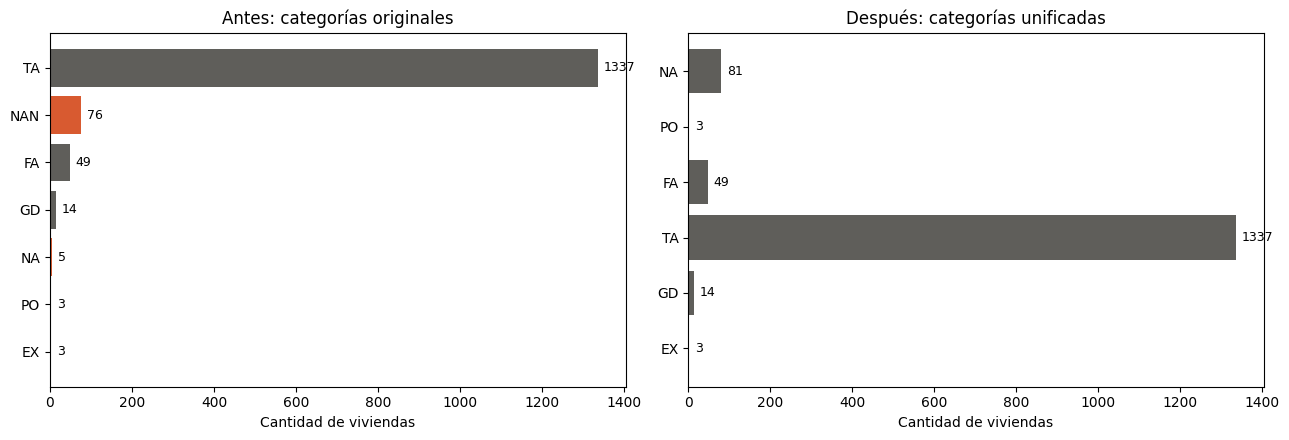

In [ ]:
#GarageQual

df_antes = df['GarageQual'].copy()
df['GarageQual'].value_counts(dropna=False)
#Se puede observar que hay una falsa categoría: NaN y NA porbablemente hagan referencia a la clase "Na": que no tiene garage.
#Estrategia adoptadas: pasamos todo a mayúsculas, y fusionamos estas dos categorías.
df['GarageQual'] = df['GarageQual'].str.strip().str.upper() # strip() elimina espacios en blanco al principio y al final de cada texto.
#Vamos a determinar si los NaN son faltantes o si hacen referencia a la categoría "Na"
display(df.loc[df['GarageQual'].isna(), 'GarageArea'].value_counts()) #Podemos ver que todos los NaN de GarageQual eran en realidad "Na" (o indica que no hay garage)

sin_garage = df['GarageArea'] == 0
df.loc[sin_garage, 'GarageQual'] = 'NA'
orden_calidad_Grid = CategoricalDtype(categories = ['NA', 'PO', 'FA', 'TA', 'GD', 'EX'], ordered = True)
df['GarageQual'] = df['GarageQual'].astype(orden_calidad_Grid)
assert df['GarageQual'].isna().sum() == 0, "Quedaron valores sin mapear al hacer el cast"

graficar_antes_despues_categorias(antes_crudo=df_antes, despues=df['GarageQual'], orden_final=['NA', 'PO', 'FA', 'TA', 'GD', 'EX'])

Por ultimo , nos queda verificar la razon de los valores nulos de Lot frontage:

In [ ]:
# Filtramos el dataframe para quedarnos solo con los LotFrontage nulos
nulos_lotfrontage = df[df['LotFrontage'].isna()]

print("\n--- Dataset completo de las casas sin LotFrontage ---")
display(nulos_lotfrontage)


--- Dataset completo de las casas sin LotFrontage ---


,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
0,87500,RL,NAmes,NaN,8544,4,1949,2,2,TA,400,0,NONE,NONE
2,144000,RM,CollgCr,NaN,4435,5,2003,1,1,TA,420,0,NONE,NONE
4,130500,RL,Sawyer,NaN,13517,8,1976,2,3,TA,475,0,NONE,NONE
7,112000,RL,Mitchel,NaN,8780,5,1985,1,3,NA,0,0,NONE,MnPrv
13,157900,RL,Mitchel,NaN,26142,7,1962,1,3,TA,312,0,NONE,NONE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1437,222000,RL,Crawfor,NaN,21695,9,1988,2,3,TA,540,0,NONE,NONE
1441,163500,RL,NAmes,NaN,12155,3,1970,2,3,TA,484,0,NONE,NONE
1446,302000,RL,ClearCr,NaN,115149,5,1971,2,2,TA,739,0,NONE,NONE
1455,244400,RL,ClearCr,NaN,24090,7,1940,2,4,TA,349,0,NONE,NONE


In [ ]:
# Filtramos las propiedades donde LotFrontage es nulo
nulos_df = df[df['LotFrontage'].isna()]

tabla_zona = (
    nulos_df['MSZoning']
    .value_counts()
    .reset_index()
)
tabla_zona.columns = ['Tipo de Zona (MSZoning)', 'Cantidad de Nulos']

print("--- Nulos de LotFrontage por Tipo de Zona ---")
display(tabla_zona)

tabla_barrio = (
    nulos_df['Neighborhood']
    .value_counts()
    .reset_index()
)
tabla_barrio.columns = ['Barrio (Neighborhood)', 'Cantidad de Nulos']

print("\n--- Nulos de LotFrontage por Barrio ---")
display(tabla_barrio)

--- Nulos de LotFrontage por Tipo de Zona ---


,Tipo de Zona (MSZoning),Cantidad de Nulos
0,RL,232
1,RM,21
2,FV,8
3,RH,3



--- Nulos de LotFrontage por Barrio ---


,Barrio (Neighborhood),Cantidad de Nulos
0,NAmes,39
1,NWAmes,30
2,Gilbert,30
3,Sawyer,26
4,CollgCr,25
5,ClearCr,15
6,Mitchel,13
7,Crawfor,10
8,SawyerW,9
9,Edwards,9


Bingo! Los valores nulos coinciden casi en su totalidad con las cas en la zona RL! es un mnar... o no?

Para verifivar esto, vamos a hcer un poco de EDA Y verificar las proporciones:

In [ ]:
import pandas as pd

# Filtro booleano de nulos en LotFrontage
es_nulo = df['LotFrontage'].isna()

total_zona = df['MSZoning'].value_counts()
nulos_zona = df[es_nulo]['MSZoning'].value_counts()

tabla_zona = pd.DataFrame({
    'Total Casos': total_zona,
    'Cantidad Nulos': nulos_zona,
    'Porcentaje Nulos (%)': (nulos_zona / total_zona) * 100
}).fillna({'Cantidad Nulos': 0, 'Porcentaje Nulos (%)': 0})

tabla_zona['Cantidad Nulos'] = tabla_zona['Cantidad Nulos'].astype(int)
tabla_zona = tabla_zona.sort_values(by='Porcentaje Nulos (%)', ascending=False)

print("--- Nulos de LotFrontage por Tipo de Zona (MSZoning) ---")
display(
    tabla_zona.style
    .format({'Porcentaje Nulos (%)': "{:.2f}%"})
    .background_gradient(subset=['Porcentaje Nulos (%)'], cmap='Reds')
)
total_barrio = df['Neighborhood'].value_counts()
nulos_barrio = df[es_nulo]['Neighborhood'].value_counts()

tabla_barrio = pd.DataFrame({
    'Total Casos': total_barrio,
    'Cantidad Nulos': nulos_barrio,
    'Porcentaje Nulos (%)': (nulos_barrio / total_barrio) * 100
}).fillna({'Cantidad Nulos': 0, 'Porcentaje Nulos (%)': 0})

tabla_barrio['Cantidad Nulos'] = tabla_barrio['Cantidad Nulos'].astype(int)
tabla_barrio = tabla_barrio.sort_values(by='Porcentaje Nulos (%)', ascending=False)

print("\n--- Nulos de LotFrontage por Barrio (Neighborhood) ---")
display(
    tabla_barrio.style
    .format({'Porcentaje Nulos (%)': "{:.2f}%"})
    .background_gradient(subset=['Porcentaje Nulos (%)'], cmap='Reds')
)

--- Nulos de LotFrontage por Tipo de Zona (MSZoning) ---


,Total Casos,Cantidad Nulos,Porcentaje Nulos (%)
MSZoning,,,
RL,1173,232,19.78%
RH,16,3,18.75%
FV,66,8,12.12%
RM,222,21,9.46%
C (ALL),10,0,0.00%



--- Nulos de LotFrontage por Barrio (Neighborhood) ---


,Total Casos,Cantidad Nulos,Porcentaje Nulos (%)
Neighborhood,,,
ClearCr,28,15,53.57%
NWAmes,77,30,38.96%
Gilbert,81,30,37.04%
Veenker,11,4,36.36%
Sawyer,75,26,34.67%
Mitchel,50,13,26.00%
NPkVill,9,2,22.22%
Timber,38,8,21.05%
StoneBr,25,5,20.00%


Viendo los datos podemos llegar a la conclusion de que se trata de un MCAR  y los datos nulos quedan fianlemnte asi:

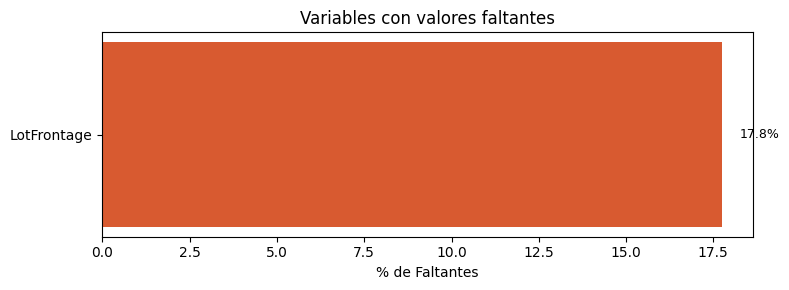

In [ ]:


resumen = armar_resumen(df)

graficar_faltantes(resumen, umbral=0)


##Seccion 2.2

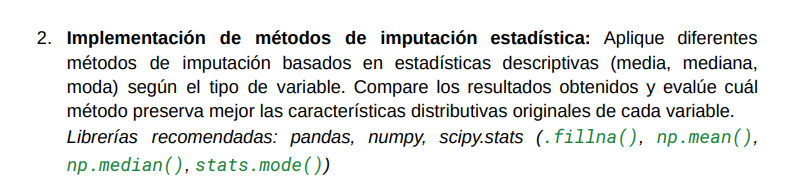

In [ ]:
display(armar_resumen(df))
col_numericas = df.select_dtypes(include=[np.number]).columns
missing_numerico = resumen.loc[resumen.index.isin(col_numericas) & (resumen['% de Faltantes'] > 0)]
display(missing_numerico)

In [ ]:
skewness_lotfrontage = df['LotFrontage'].skew()
print(f"Asimetría de LotFrontage: {skewness_lotfrontage:.3f}")

In [ ]:
# Histograma + KDE de LotFrontage, con líneas de media/mediana superpuestas
# para que se vea a simple vista cómo la cola derecha "arrastra" la media
# lejos del centro de masa real de los datos (por eso conviene mediana)
datos_lotfrontage = df['LotFrontage'].dropna()
media = datos_lotfrontage.mean()
mediana = datos_lotfrontage.median()
moda = datos_lotfrontage.mode()[0]

plt.figure(figsize=(10, 5))
sns.histplot(datos_lotfrontage, kde=True, color='#4C72B0', bins=40)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media = {media:.1f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana = {mediana:.1f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda = {moda:.1f}')
plt.title(f'Distribución de LotFrontage (skew = {skewness_lotfrontage:.2f})')
plt.xlabel('LotFrontage (pies lineales de calle)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cada imputación se calcula sobre una copia de la serie original (fillna
# no es in-place acá) para poder superponerlas sin pisar df ni entre sí
serie_original = df['LotFrontage']
imputado_media = serie_original.fillna(media)
imputado_mediana = serie_original.fillna(mediana)
imputado_moda = serie_original.fillna(moda)

plt.figure(figsize=(10, 5))
sns.kdeplot(datos_lotfrontage, label='Original (sin faltantes)', color='black', linewidth=2)
sns.kdeplot(imputado_media, label='Imputado con media', color='red', linestyle='--')
sns.kdeplot(imputado_mediana, label='Imputado con mediana', color='green', linestyle='--')
sns.kdeplot(imputado_moda, label='Imputado con moda', color='purple', linestyle='--')
plt.title('Comparación de distribuciones: original vs. imputaciones (LotFrontage)')
plt.xlabel('LotFrontage (pies lineales de calle)')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()


##Seccion 2.3

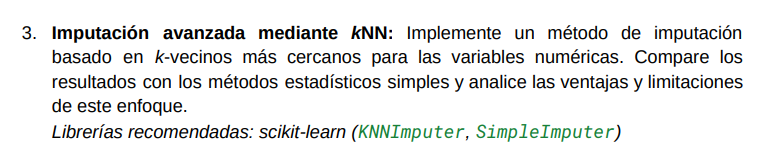

In [ ]:
#Primero hacemos un heatmap para indicar las variables mas correlacionadas con la de interes para que el knn
#pueda usarlas para imputar correctamente

df_numerico = df.select_dtypes(include=[np.number])
correlacion = df_numerico.corr()

#Generar una máscara booleana para el triángulo superior (incluye la diagonal)
mascara = np.triu(np.ones_like(correlacion, dtype=bool), k = 1)

plt.figure(figsize=(10, 5))

sns.heatmap(
    correlacion,
    mask=mascara,
    cmap='coolwarm',       # Escala divergente: rojo (positiva), azul (negativa)
    annot=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlación de Variables Numéricas (House Prices)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


De esta manera, seleccionamos GarageArea, BedroomAbvGr y PoolArea

In [ ]:
#Imputacion por KNN para la variable LotFrontage

columnas_knn = ['LotFrontage', 'GarageArea', 'PoolArea', 'BedroomAbvGr']
df_knn = df[columnas_knn].copy()

#Aplicamos KNNImputer
imputador_knn = KNNImputer(n_neighbors=5) #usamos la cantidad estandar de la funcion
df_imputado_array = imputador_knn.fit_transform(df_knn)

#Reconstruimos un DataFrame temporal con los datos imputados para graficar
df_imputado = pd.DataFrame(df_imputado_array, columns=columnas_knn)

#Gráfico de densidad superpuesto (KDE)
plt.figure(figsize=(10, 6))

#Distribución original ignorando los valores nulos (dropna)
sns.kdeplot(df['LotFrontage'].dropna(),
            label='Original (Ignorando NaNs)',
            color='blue',
            linewidth=2)

#Distribución con los valores imputados por KNN
sns.kdeplot(df_imputado['LotFrontage'],
            label='Imputado (KNN, k=5)',
            color='orange',
            linestyle='--',
            linewidth=2)

plt.title('Distribución de LotFrontage: Original vs KNN Imputer')
plt.xlabel('LotFrontage (Pies lineales de calle)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

EL KNN ES CLAVE

#Ejercicio 3

##Seccion 3.1

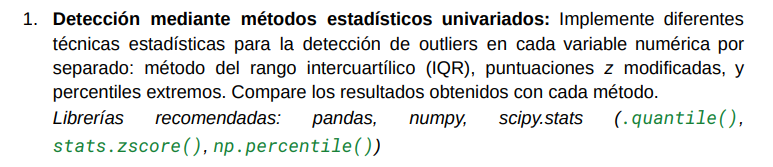

SalePrice

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['SalePrice'].quantile(0.25)
q3 = df['SalePrice'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['SalePrice'].quantile(0.01)
p_sup = df['SalePrice'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['SalePrice'].median()
mad = stats.median_abs_deviation(df['SalePrice'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['SalePrice'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en SalePrice', fontsize=13)
plt.xlabel('SalePrice')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

LotFrontage

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['LotFrontage'].quantile(0.25)
q3 = df['LotFrontage'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['LotFrontage'].quantile(0.01)
p_sup = df['LotFrontage'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['LotFrontage'].median()
mad = stats.median_abs_deviation(df['LotFrontage'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['LotFrontage'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en LotFrontage', fontsize=13)
plt.xlabel('LotFrontage')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

LotArea

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['LotArea'].quantile(0.25)
q3 = df['LotArea'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['LotArea'].quantile(0.01)
p_sup = df['LotArea'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['LotArea'].median()
mad = stats.median_abs_deviation(df['LotArea'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['LotArea'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en LotArea', fontsize=13)
plt.xlabel('LotArea')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

YearBuilt

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['YearBuilt'].quantile(0.25)
q3 = df['YearBuilt'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['YearBuilt'].quantile(0.01)
p_sup = df['YearBuilt'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['YearBuilt'].median()
mad = stats.median_abs_deviation(df['YearBuilt'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['YearBuilt'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en YearBuilt', fontsize=13)
plt.xlabel('YearBuilt')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

FullBath



In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['FullBath'].quantile(0.25)
q3 = df['FullBath'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['FullBath'].quantile(0.01)
p_sup = df['FullBath'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['FullBath'].median()
mad = stats.median_abs_deviation(df['FullBath'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['FullBath'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en FullBath', fontsize=13)
plt.xlabel('FullBath')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

BedroomAbvGr

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['BedroomAbvGr'].quantile(0.25)
q3 = df['BedroomAbvGr'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['BedroomAbvGr'].quantile(0.01)
p_sup = df['BedroomAbvGr'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['BedroomAbvGr'].median()
mad = stats.median_abs_deviation(df['BedroomAbvGr'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['BedroomAbvGr'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en BedroomAbvGr', fontsize=13)
plt.xlabel('BedroomAbvGr')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

GarageArea

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['GarageArea'].quantile(0.25)
q3 = df['GarageArea'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['GarageArea'].quantile(0.01)
p_sup = df['GarageArea'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['GarageArea'].median()
mad = stats.median_abs_deviation(df['GarageArea'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['GarageArea'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en GarageArea', fontsize=13)
plt.xlabel('GarageArea')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

PoolArea

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['PoolArea'].quantile(0.25)
q3 = df['PoolArea'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['PoolArea'].quantile(0.01)
p_sup = df['PoolArea'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['PoolArea'].median()
mad = stats.median_abs_deviation(df['PoolArea'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['PoolArea'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en PoolArea', fontsize=13)
plt.xlabel('PoolArea')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

Alternativa (Variables juntas en un solo grafico)

In [ ]:
#Lista de variables a analizar
variables = [
    'SalePrice', 'LotFrontage', 'LotArea', 'YearBuilt',
    'FullBath', 'BedroomAbvGr', 'GarageArea', 'PoolArea'
]

#Configuración del lienzo: 2 filas x 4 columnas
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(variables):
    ax = axes[i]

    serie = df[col].dropna()

    #Método IQR (1.5 * IQR)
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    #Método Percentiles (1% y 99%)
    p_inf = serie.quantile(0.01)
    p_sup = serie.quantile(0.99)

    #Método Z-score Modificado (corte = 3.5)
    mediana = serie.median()
    mad = stats.median_abs_deviation(serie)

    #Control para distribuciones con MAD = 0 (ej. variables discretas o con muchos ceros como PoolArea)
    if mad != 0:
        zmod_inf = mediana - (3.5 * mad) / 0.6745
        zmod_sup = mediana + (3.5 * mad) / 0.6745
    else:
        zmod_inf, zmod_sup = np.nan, np.nan

    #Histograma y curva de densidad (KDE adaptativo si hay suficiente varianza)
    use_kde = True if serie.nunique() > 10 else False
    sns.histplot(serie, ax=ax, kde=use_kde, color='#B0BEC5', stat='density', bins=30, edgecolor='white')

    #Trazado de líneas de umbral (IQR: Rojo, Percentiles: Naranja, Z-mod: Azul)
    ax.axvline(iqr_inf, color='#D32F2F', linestyle='--', linewidth=1.5, label='IQR (1.5)')
    ax.axvline(iqr_sup, color='#D32F2F', linestyle='--', linewidth=1.5)

    ax.axvline(p_inf, color='#F57C00', linestyle=':', linewidth=1.8, label='Perc (1%-99%)')
    ax.axvline(p_sup, color='#F57C00', linestyle=':', linewidth=1.8)

    if not np.isnan(zmod_inf):
        ax.axvline(zmod_inf, color='#1976D2', linestyle='-.', linewidth=1.5, label='Z-mod (3.5)')
        ax.axvline(zmod_sup, color='#1976D2', linestyle='-.', linewidth=1.5)

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Densidad' if i % 4 == 0 else '')
    ax.grid(axis='y', linestyle=':', alpha=0.6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, frameon=True, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

##Secccion 3.2

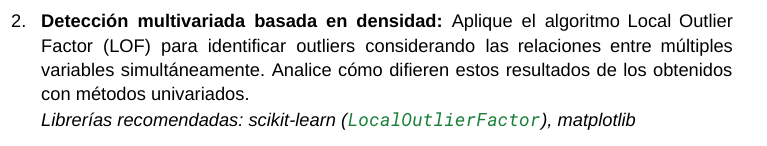

### Comparación: outliers univariados (IQR) vs. multivariados (LOF)

Los métodos univariados (IQR) analizan cada variable de forma aislada, por lo que
no detectan un caso "normal" en cada atributo por separado pero atípico en su
combinación. LOF sí captura ese tipo de atípico porque mide
densidad local en el espacio conjunto de las 9 variables. Para cuantificar en qué
medida ambos métodos coinciden o difieren, cruzamos los dos flags binarios en una
tabla de contingencia y aplicamos un test de chi-cuadrado de independencia. La visualización se hace sobre la proyección PCA ya calculada,
usada aquí únicamente para visualizar, no
para detectar outliers. LOF corrió sobre las 9 variables originales
estandarizadas.


In [ ]:
# --- Datos para detección multivariada ---
import numpy as np
import pandas as pd

variables = [
    'LotFrontage',
    'LotArea',
    'OverallCond',
    'YearBuilt',
    'FullBath',
    'BedroomAbvGr',
    'GarageArea',
    'PoolArea',
    'SalePrice'
]

df_lof = df[variables].dropna().copy()

print(f"{len(df_lof)} observaciones en {len(variables)} dimensiones")

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

# Escalado de las variables
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_lof[variables])

# --- Detección Multivariada (LOF) ---
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
pred_lof = lof.fit_predict(datos_escalados)
df_lof['outlier_lof'] = pred_lof == -1

In [ ]:
# --- Visualización de los outliers detectados por LOF ---

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
datos_pca = pca.fit_transform(datos_escalados)

df_lof['PC1'] = datos_pca[:, 0]
df_lof['PC2'] = datos_pca[:, 1]

plt.figure(figsize=(8, 6))

plt.scatter(
    df_lof.loc[~df_lof['outlier_lof'], 'PC1'],
    df_lof.loc[~df_lof['outlier_lof'], 'PC2'],
    label='Normal',
    alpha=0.7
)

plt.scatter(
    df_lof.loc[df_lof['outlier_lof'], 'PC1'],
    df_lof.loc[df_lof['outlier_lof'], 'PC2'],
    color='red',
    marker='x',
    s=60,
    label='Outlier (LOF)'
)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Detección Multivariada de Outliers con LOF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- Detección Univariada (IQR) ---

variables = [
    'LotFrontage',
    'LotArea',
    'OverallCond',
    'YearBuilt',
    'FullBath',
    'BedroomAbvGr',
    'GarageArea',
    'PoolArea',
    'SalePrice'
]

df_iqr = df[variables].copy()

outliers_iqr = pd.DataFrame(index=df_iqr.index)

for variable in variables:
    q1 = df_iqr[variable].quantile(0.25)
    q3 = df_iqr[variable].quantile(0.75)
    iqr = q3 - q1

    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers_iqr[variable] = (
        (df_iqr[variable] < lim_inf) |
        (df_iqr[variable] > lim_sup)
    )

# Una observación es outlier IQR si lo es en al menos una variable
df_iqr['outlier_iqr'] = outliers_iqr.any(axis=1)

print("Outliers detectados por IQR:", df_iqr['outlier_iqr'].sum())

In [ ]:
from IPython.display import display
# --- Comparacion: outliers univariados (IQR) vs. multivariados (LOF) ---
# LOF solo se calculo sobre las filas sin NaN (df_lof), mientras que el IQR
# se calculo sobre todo df_iqr. Restringimos la comparacion a df_lof.index
# para que sea 1 a 1 (misma logica que U2-T-01 pp. 15-21: comparar el mismo
# conjunto de observaciones bajo ambos criterios).
comparacion = pd.DataFrame({
    'outlier_iqr': df_iqr.loc[df_lof.index, 'outlier_iqr'],
    'outlier_lof': df_lof['outlier_lof']
})

# Tabla de contingencia (U1-T-01, pp. 7-10): outlier_iqr y outlier_lof son
# dos variables categoricas binarias, exactamente el caso de uso del capitulo.
tabla = pd.crosstab(comparacion['outlier_iqr'], comparacion['outlier_lof'])

# Test chi-cuadrado de independencia (U1-T-01, pp. 7-10). H0: los dos
# criterios de deteccion son independientes entre si.
chi2, p, gl, esperado = stats.chi2_contingency(tabla)
print(f"chi2 = {chi2:.2f}  gl = {gl}  p-valor = {p:.3g}\n")


# Reemplazamos print(tabla) por un Styler: mismos datos, pero renderizados
# como tabla real del notebook (con bordes, header y color) en vez de texto
# plano de consola — más fácil de leer para comparar IQR vs. LOF de un vistazo
tabla_estilizada = (
    tabla.style
    .set_caption('Tabla de contingencia')
    .background_gradient(cmap='Blues')
    .format(precision=0)
)
display(tabla_estilizada)

In [ ]:
# --- Visualizacion sobre la proyeccion PCA (celda anterior) ---
# El PCA se usa aca solo para graficar en 2D (rol de Unidad 1, U1-T-01 pp. 20-23),
# no para detectar: LOF ya corrio sobre las 9 variables originales estandarizadas,
# nunca sobre PC1/PC2 (U1-T-01 p. 21, argumento de la maldicion de la dimensionalidad).
categoria = np.select(
    [comparacion['outlier_iqr'] & comparacion['outlier_lof'],
     comparacion['outlier_iqr'] & ~comparacion['outlier_lof'],
     ~comparacion['outlier_iqr'] & comparacion['outlier_lof']],
    ['Ambos', 'Solo IQR', 'Solo LOF'],
    default='Ninguno'
)

plt.figure(figsize=(8, 6))
for cat, color, marker in [('Ninguno', '#B0BEC5', 'o'), ('Solo IQR', '#F57C00', 's'),
                            ('Solo LOF', '#D32F2F', 'x'), ('Ambos', '#1976D2', '^')]:
    mask = categoria == cat
    plt.scatter(df_lof.loc[mask, 'PC1'], df_lof.loc[mask, 'PC2'],
                label=cat, alpha=0.7, marker=marker, c=color)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Outliers univariados (IQR) vs. multivariados (LOF)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


##Sección 3.3

****

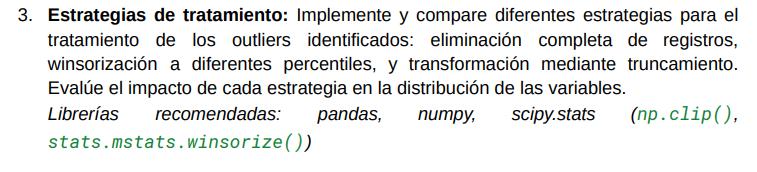

In [ ]:
def clasificar_naturaleza_outlier(es_outlier_iqr_var, es_outlier_lof):
    """Cruza el flag univariado (IQR, específico de una variable) con el
    multivariado (LOF, sobre el conjunto de 9 variables) para decidir
    tratamiento según el tipo de outlier: extremo aislado en esa columna
    vs. atípico en combinación con el resto vs. ambas cosas a la vez.
    Distingue aparte las filas que LOF nunca evaluó (dropna previo por
    faltantes en alguna de las 9 variables) — tratarlas como 'normal'
    sería incorrecto, no es que LOF las haya descartado, no las vio."""
    lof_alineado = es_outlier_lof.reindex(es_outlier_iqr_var.index)
    evaluado_por_lof = lof_alineado.notna()

    # reindex sube el dtype a float64 para poder representar los NaN de las
    # filas no evaluadas; volvemos a bool con un placeholder (False) que es
    # seguro porque esas filas ya quedan cubiertas por evaluado_por_lof antes
    # de llegar a usarse en las ramas que niegan/leen lof_alineado
    lof_bool = lof_alineado.fillna(False).astype(bool)

    categoria = pd.Series('normal', index=es_outlier_iqr_var.index)
    categoria[es_outlier_iqr_var & ~evaluado_por_lof] = 'solo_iqr_sin_lof'
    categoria[es_outlier_iqr_var & evaluado_por_lof & lof_bool] = 'ambos'
    categoria[es_outlier_iqr_var & evaluado_por_lof & ~lof_bool] = 'solo_iqr'
    categoria[~es_outlier_iqr_var & evaluado_por_lof & lof_bool] = 'solo_lof'
    return categoria


In [ ]:
categoria_lotarea = clasificar_naturaleza_outlier(outliers_iqr['LotArea'], df_lof['outlier_lof'])
categoria_lotarea.value_counts()
variables_outliers = [
    'LotFrontage', 'LotArea', 'OverallCond', 'YearBuilt',
    'FullBath', 'BedroomAbvGr', 'GarageArea', 'PoolArea', 'SalePrice'
]

resumen_naturaleza = pd.DataFrame({
    variable: clasificar_naturaleza_outlier(outliers_iqr[variable], df_lof['outlier_lof']).value_counts()
    for variable in variables_outliers
}).fillna(0).astype(int)

resumen_naturaleza


In [ ]:
from scipy.stats.mstats import winsorize

def eliminar_outliers(df, es_outlier):
    """Elimina por completo las filas marcadas en `es_outlier` (máscara
    booleana alineada al índice de df). Es la estrategia más agresiva:
    pierde toda la información de esas observaciones, no solo la variable
    problemática — por eso reservada para los casos con evidencia más
    fuerte (ej. categoría 'ambos' de la clasificación anterior)."""
    return df.loc[~es_outlier].copy()


def winsorizar(serie, limite_inferior, limite_superior):
    """Winsoriza los valores observados de la serie (reemplaza los extremos
    por el percentil de corte, no los elimina). Los faltantes quedan
    intactos: winsorizar y tratar NaN son problemas independientes, no
    corresponde imputar acá. Devuelve una copia."""
    serie_tratada = serie.copy()
    mascara_validos = serie.notna()
    serie_tratada[mascara_validos] = winsorize(
        serie[mascara_validos], limits=(limite_inferior, limite_superior)
    )
    return serie_tratada


def truncar(serie, limite_inferior, limite_superior):
    """Trunca (clip) los valores observados a un límite fijo, en vez de a un
    percentil relativo como winsorizar — la diferencia conceptual entre
    ambas es justamente eso: percentil de la muestra vs. umbral externo
    (acá, típicamente los límites IQR ya calculados). np.clip propaga NaN
    sin tocarlos, así que los faltantes también quedan intactos."""
    return pd.Series(
        np.clip(serie, limite_inferior, limite_superior),
        index=serie.index, name=serie.name,
    )


In [ ]:
variables_tratamiento = ['LotFrontage', 'LotArea', 'SalePrice', 'GarageArea', 'YearBuilt', 'BedroomAbvGr']

def calcular_limites_iqr(serie):
    """1.5xIQR (regla de Tukey) — mismo criterio ya usado para armar
    'outliers_iqr' en la Sección 3.1, para que truncar() sea consistente
    con la detección que alimentó la clasificación de naturaleza."""
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

limites_iqr = {
    variable: calcular_limites_iqr(df[variable])
    for variable in variables_tratamiento
}
limites_iqr


In [ ]:
tratamientos_por_variable = {}
tablas_comparacion_por_variable = {}

def analizar_tratamientos_variable(variable):
    """Corre tabla + boxplot + histogramas para una sola variable — pensada
    para tener una celda por variable, igual que el resto de la Sección 3.1,
    en vez de un loop que tira todo junto en una sola celda."""
    tratamientos = aplicar_tratamientos(df, variable, categorias_por_variable, limites_iqr, niveles_winsorizacion)
    tratamientos_por_variable[variable] = tratamientos

    tabla = pd.DataFrame([
        comparar_distribucion(df[variable], serie_tratada, nombre)
        for nombre, serie_tratada in tratamientos.items()
    ])
    tablas_comparacion_por_variable[variable] = tabla

    display(
        tabla.round(2).style
        .set_caption(f'Comparación de estrategias de tratamiento — {variable}')
        .background_gradient(subset=['estadistico_ks'], cmap='Reds')
    )

    datos_boxplot = pd.DataFrame({'Original': df[variable], **tratamientos})
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=datos_boxplot, orient='h')
    plt.title(f'{variable}: boxplot por estrategia de tratamiento')
    plt.tight_layout()
    plt.show()

    versiones = {'Original': df[variable], **tratamientos}
    fig, axes = plt.subplots(nrows=1, ncols=len(versiones), figsize=(4 * len(versiones), 3.5), sharey=True)
    for ax, (nombre, serie) in zip(axes, versiones.items()):
        sns.histplot(serie.dropna(), kde=True, ax=ax, color='#4C72B0', bins=30)
        ax.set_title(nombre, fontsize=9)
        ax.set_xlabel('')
    fig.suptitle(f'{variable}: distribución por estrategia', y=1.03)
    plt.tight_layout()
    plt.show()


In [ ]:
analizar_tratamientos_variable('LotFrontage')
analizar_tratamientos_variable('LotArea')
analizar_tratamientos_variable('SalePrice')
analizar_tratamientos_variable('GarageArea')
analizar_tratamientos_variable('YearBuilt')
analizar_tratamientos_variable('BedroomAbvGr')

#Ejercicio 4

##Seccion 4.1

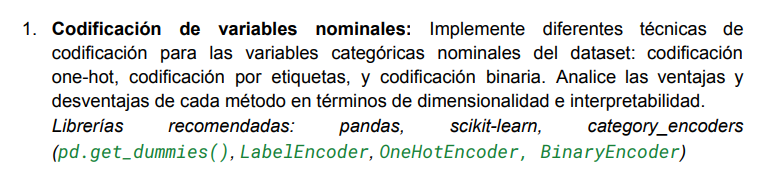

Variables nominales:



*   NeighborHood

*   MSZoning



In [ ]:
#Codificacion one-hot
df_one_hot = df.copy()
#Aplicar One-Hot Encoding
df_one_hot = pd.get_dummies(df_one_hot, columns=['Neighborhood', 'MSZoning'], dtype=int)

#Ver las columnas creadas
columnas_codificadas = [col for col in df_one_hot.columns if col.startswith(('Neighborhood_', 'MSZoning_'))]

#Mostrar las columnas codificadas
df_one_hot[columnas_codificadas].head(5)




,Neighborhood_ BrkSide,Neighborhood_ NAmes,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,...,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,MSZoning_Rh,MSZoning_rL
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
#Codificacion por etiquetas
df_label = df.copy()

#Crear los codificadores
le_neighborhood = LabelEncoder()
le_mszoning = LabelEncoder()

#Aplicar Label Encoding
df_label['Neighborhood'] = le_neighborhood.fit_transform(df_label['Neighborhood'])

df_label['MSZoning'] = le_mszoning.fit_transform(df_label['MSZoning'])

df_label[['Neighborhood', 'MSZoning']].head(5)

,Neighborhood,MSZoning
0,14,3
1,7,3
2,7,4
3,23,6
4,21,3


In [ ]:
#Codificacion binaria
df_binary =df.copy()

#Definir las columnas a codificar
columnas_categoricas = ['Neighborhood', 'MSZoning']

#Inicializar y aplicar el codificador
encoder = BinaryEncoder(cols=columnas_categoricas)
df_encoded = encoder.fit_transform(df_binary)

df_encoded[['Neighborhood', 'MSZoning']].head(5)


      SalePrice  MSZoning_0  MSZoning_1  MSZoning_2  Neighborhood_0  \
0         87500           0           0           1               0   
1        164990           0           0           1               0   
2        144000           0           1           0               0   
3        307000           0           1           1               0   
4        130500           0           0           1               0   
...         ...         ...         ...         ...             ...   
1482     270000           0           0           1               1   
1483     109008           0           0           1               0   
1484     102000           0           0           1               0   
1485     165000           0           0           1               0   
1486      81000           0           1           0               1   

      Neighborhood_1  Neighborhood_2  Neighborhood_3  Neighborhood_4  \
0                  0               0               0               1   
1  

Ventajas y Desventajas de cada método.

**One-hot Encoding:** Como principal ventaja podemos mencionar la interpretabilidad directa, ya que cada característica binaria corresponde de forma clara y explícita a una feature.

Sin embargo, esta técnica de codificación tiene como principal desventaja la llamada "maldición de la dimensionalidad". Si la variable categórica tiene una gran cantidad de valores únicos (alta cardinalidad), one-hot encoding generaría una matriz enorme que aumentaría drásticamente el costo computacional de almacenamiento, entrenamiento y predicción del modelo.

**Label Encoding:** La principal ventaja de esta codificación es que no expande la dimensionalidad del conjunto de datos, ya que condensa cualquier número de categorías en una sola columna numérica asignando valores de 0 a k-1.
Como desventaja, introduce un orden numérico espurio que distorsiona la interpretación del modelo, haciendo que relaciones inexistentes (como asumir que una categoría es mayor o menor que otra) afecten el significado de las predicciones y de los coeficientes.

**Binary Encoding:** Como principal ventaja frente a la alta cardinalidad, comprime notablemente el espacio de características al requerir solo log_2(k) columnas en lugar de k, evitando la creación de matrices masivas y dispersas.
Como desventaja, genera una pérdida total de interpretabilidad directa, ya que las nuevas columnas corresponden únicamente a bits posicionales del código binario (por ejemplo, "el segundo bit"), volviendo opaca la relación entre las características individuales y la variable objetivo.

In [ ]:
#Hacemos un one-hot encoding en el dataset original para ambas variables

#Aplicar One-Hot Encoding
pd.get_dummies(df, columns=['Neighborhood', 'MSZoning'], dtype=int)

,SalePrice,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,...,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,MSZoning_Rh,MSZoning_rL
0,87500,NaN,8544,4,1949,2,2,TA,400,0,...,0,0,0,0,0,0,1,0,0,0
1,164990,65.0,8767,5,2005,2,3,TA,400,0,...,0,0,0,0,0,0,1,0,0,0
2,144000,NaN,4435,5,2003,1,1,TA,420,0,...,0,0,0,0,0,0,0,1,0,0
3,307000,75.0,10084,5,2004,2,3,TA,636,0,...,0,0,0,0,0,0,0,0,0,1
4,130500,NaN,13517,8,1976,2,3,TA,475,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1482,270000,85.0,14536,5,2002,2,3,TA,808,0,...,0,1,0,0,0,0,1,0,0,0
1483,109008,77.0,8593,6,1957,1,3,TA,352,0,...,0,0,0,0,0,0,1,0,0,0
1484,102000,67.0,8877,5,1951,1,2,TA,396,0,...,0,0,0,0,0,0,1,0,0,0
1485,165000,100.0,9500,6,1964,1,4,TA,540,0,...,0,0,0,0,0,0,1,0,0,0


##Seccion 4.2

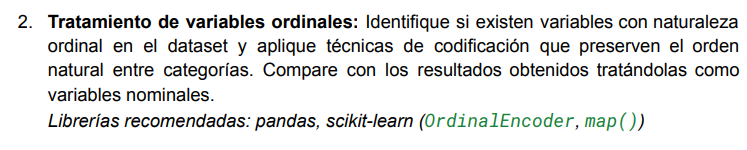

Variables Ordinales:

* OverallCond (codificada numericamente)
* GarageQual
* PoolQC
* Fence

In [ ]:
df_ordinal = df.copy()

#Diccionarios de codificación ordinal
garagequal_map = {
    'NONE': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

poolqc_map = {
    'NONE': 0,
    'Fa': 1,
    'TA': 2,
    'Gd': 3,
    'Ex': 4
}

fence_map = {
    'NONE': 0,
    'MnWw': 1,
    'GdWo': 2,
    'MnPrv': 3,
    'GdPrv': 4
}

#Aplicar la codificación
df_ordinal['GarageQual'] = df_ordinal['GarageQual'].map(garagequal_map)
df_ordinal['PoolQC'] = df_ordinal['PoolQC'].map(poolqc_map)
df_ordinal['Fence'] = df_ordinal['Fence'].map(fence_map)

In [ ]:
df_ordinal[['GarageQual', 'PoolQC', 'Fence']].tail(10)

,GarageQual,PoolQC,Fence
1477,3.0,0,0
1478,3.0,0,0
1479,3.0,0,0
1480,3.0,0,3
1481,3.0,0,3
1482,3.0,0,0
1483,3.0,0,0
1484,3.0,0,0
1485,3.0,0,4
1486,0.0,0,0


In [ ]:
#Hacemos un one-hot encoding tratando las variables como nominales para comparar
df_onehot = df.copy()

df_onehot = pd.get_dummies(df_onehot, columns=['GarageQual', 'PoolQC', 'Fence'], dtype=int)

In [ ]:
df_onehot.filter(regex='^(GarageQual|PoolQC|Fence)_').head(10)

,GarageQual_NONE,GarageQual_PO,GarageQual_FA,GarageQual_TA,GarageQual_GD,GarageQual_EX,PoolQC_Ex,PoolQC_Fa,PoolQC_Gd,PoolQC_NONE,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_NONE
0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1
1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1
2,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1
3,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1
4,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1
5,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0
6,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1
7,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0
8,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1
9,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1


Al comparar ambos tratamientos, se observa que la codificación ordinal resulta más adecuada para estas variables, ya que permite conservar la jerarquía natural existente entre sus categorías. En cambio, aunque One-Hot Encoding puede aplicarse correctamente, transforma cada categoría en una variable independiente y, por lo tanto, elimina dicha relación de orden, perdiendo información relevante que puede ser aprovechada por el modelo.


In [ ]:
#Aplicamos el mapeo al dataset original
df['GarageQual'] = df['GarageQual'].map(garagequal_map)
df['PoolQC'] = df['PoolQC'].map(poolqc_map)
df['Fence'] = df['Fence'].map(fence_map)

##Seccion 4.3

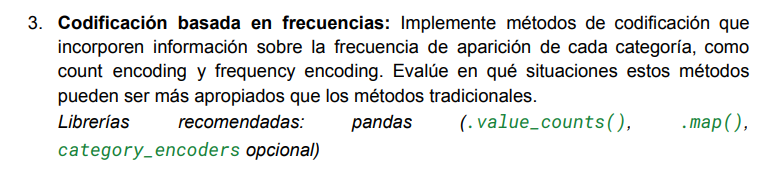

In [ ]:
columnas = [
    'Neighborhood',
    'MSZoning',
    'OverallCond',
    'GarageQual',
    'PoolQC',
    'Fence'
]

#Codificacion por conteo

df_count = df.copy()

#Conteo de cada categoría para cada variable
df_count['Neighborhood'] = df_count['Neighborhood'].map(df['Neighborhood'].value_counts())

df_count['MSZoning'] = df_count['MSZoning'].map(df['MSZoning'].value_counts())

df_count['OverallCond'] = df_count['OverallCond'].map(df['OverallCond'].value_counts())

df_count['GarageQual'] = df_count['GarageQual'].map(df['GarageQual'].value_counts())

df_count['PoolQC'] = df_count['PoolQC'].map(df['PoolQC'].value_counts())

df_count['Fence'] = df_count['Fence'].map(df['Fence'].value_counts())


df_count[columnas].head(10)

,Neighborhood,MSZoning,OverallCond,GarageQual,PoolQC,Fence
0,227,1173,58,1337,1480,NaN
1,156,1173,841,1337,1480,NaN
2,156,222,841,1337,1480,NaN
3,87,1173,841,1337,1480,NaN
4,75,1173,72,1337,1480,NaN
5,227,1173,841,1337,1480,62.0
6,42,1173,841,1337,1480,NaN
7,50,1173,841,81,1480,161.0
8,60,1173,841,1337,1480,NaN
9,51,1173,207,1337,1480,NaN


In [ ]:
#Codificacion por frequencia
df_frequency = df.copy()

#Frecuencia de cada categoría para cada variable
df_frequency['Neighborhood'] = df_frequency['Neighborhood'].map(df['Neighborhood'].value_counts(normalize=True))

df_frequency['MSZoning'] = df_frequency['MSZoning'].map(df['MSZoning'].value_counts(normalize=True))

df_frequency['OverallCond'] = df_frequency['OverallCond'].map(df['OverallCond'].value_counts(normalize=True))

df_frequency['GarageQual'] = df_frequency['GarageQual'].map(df['GarageQual'].value_counts(normalize=True))

df_frequency['PoolQC'] = df_frequency['PoolQC'].map(df['PoolQC'].value_counts(normalize=True))

df_frequency['Fence'] = df_frequency['Fence'].map(df['Fence'].value_counts(normalize=True))

df_frequency[columnas].head(10)

,Neighborhood,MSZoning,OverallCond,GarageQual,PoolQC,Fence
0,0.152656,0.788837,0.039005,0.899126,0.995293,NaN
1,0.104909,0.788837,0.565568,0.899126,0.995293,NaN
2,0.104909,0.149294,0.565568,0.899126,0.995293,NaN
3,0.058507,0.788837,0.565568,0.899126,0.995293,NaN
4,0.050437,0.788837,0.048420,0.899126,0.995293,NaN
5,0.152656,0.788837,0.565568,0.899126,0.995293,0.208054
6,0.028245,0.788837,0.565568,0.899126,0.995293,NaN
7,0.033625,0.788837,0.565568,0.054472,0.995293,0.540268
8,0.040350,0.788837,0.565568,0.899126,0.995293,NaN
9,0.034297,0.788837,0.139206,0.899126,0.995293,NaN


In [ ]:
#Tabla comparativa con una sola variable
comparacion = pd.DataFrame({
    'Original': df['Neighborhood'].head(10),
    'Count': df_count['Neighborhood'].head(10),
    'Frequency': df_frequency['Neighborhood'].head(10)
})

comparacion

,Original,Count,Frequency
0,NAmes,227,0.152656
1,CollgCr,156,0.104909
2,CollgCr,156,0.104909
3,Somerst,87,0.058507
4,Sawyer,75,0.050437
5,NAmes,227,0.152656
6,NoRidge,42,0.028245
7,Mitchel,50,0.033625
8,SawyerW,60,0.040350
9,Crawfor,51,0.034297


La codificación por conteo y por frecuencia resulta especialmente conveniente para variables categóricas de alta cardinalidad, ya que permite representar cada variable mediante una única columna, evitando el aumento dimensional que produciría One-Hot Encoding. Además, al incorporar la frecuencia de aparición de cada categoría, puede proporcionar información útil para determinados modelos, especialmente los basados en árboles. A diferencia de las técnicas de codificación supervisadas, estos métodos no requieren utilizar la variable objetivo para generar la representación, reduciendo así el riesgo de fuga de información asociada al target.


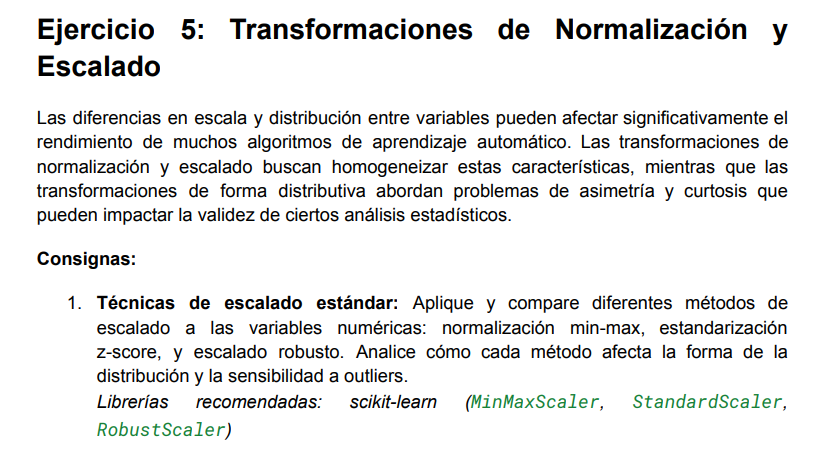

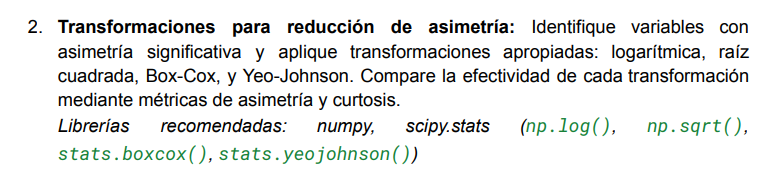

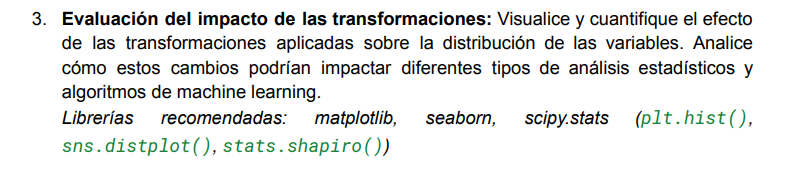